In [2]:
import pandas as pd 
from dotenv import load_dotenv
import os
import psycopg2

In [3]:
load_dotenv()
url = os.getenv('DATABASE_URL')

In [4]:
import sys
sys.path.append('..')
from src import backtester

In [5]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

In [6]:
cur.execute("""
SELECT DISTINCT ticker FROM orderbooks
""")
rows = cur.fetchall()
tickers = [row[0] for row in rows]

In [10]:
from tqdm import tqdm
import time
returns = {}
for ticker in tqdm(tickers):
    while True:
        try:
            option_df, orders_df = backtester.load_datasets(url, ticker)
            break
        except Exception as e:
            print(e)
            time.sleep(20)
    returns[ticker] = backtester.run_backtest(option_df, orders_df, fee=0.00, plot=False)

 75%|███████████████████████████████████████████████████████████████████████████████████████████████████████▉                                   | 160/214 [15:07<05:04,  5.65s/it]

(psycopg2.OperationalError) could not translate host name "interchange.proxy.rlwy.net" to address: Name or service not known

(Background on this error at: https://sqlalche.me/e/20/e3q8)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 214/214 [20:27<00:00,  5.74s/it]


{'SR270CC6D': 0,
 'SR270CD6': 0.15764199999999984,
 'SR270CD6A': 0,
 'SR270CD6B': 0,
 'SR270CD6D': 0,
 'SR270CD6E': 0,
 'SR270CE6': -0.23143500000000022,
 'SR270CE6A': 0,
 'SR270CE6B': 0,
 'SR270CE6D': 0,
 'SR270CF6': 0,
 'SR270CP6': 0.0,
 'SR270CP6A': 0,
 'SR270CP6B': 0,
 'SR270CP6D': 0,
 'SR270CP6E': 0,
 'SR270CQ6': 0.004257999999999993,
 'SR270CQ6A': 0,
 'SR270CQ6B': 0,
 'SR270CR6': nan,
 'SR280CC6D': 0,
 'SR280CD6': -0.14823900000000031,
 'SR280CD6A': -0.013271999999999388,
 'SR280CD6B': 0.0021279999999998835,
 'SR280CD6D': 0,
 'SR280CD6E': 0,
 'SR280CE6': 0.0,
 'SR280CE6A': 0,
 'SR280CE6B': 0,
 'SR280CE6D': 0,
 'SR280CF6': 0,
 'SR280CP6': 0.0,
 'SR280CP6A': nan,
 'SR280CP6B': nan,
 'SR280CP6D': 0,
 'SR280CP6E': 0,
 'SR280CQ6': 0.0068340000000000145,
 'SR280CQ6A': 0,
 'SR280CQ6B': 0,
 'SR280CR6': 0,
 'SR290CC6D': 0.0,
 'SR290CD6': 0.26676700000000053,
 'SR290CD6A': -0.4468520000000004,
 'SR290CD6B': 0.5236019999999997,
 'SR290CD6D': 1.1353709999999992,
 'SR290CD6E': 0.633819,
 'SR2

In [41]:
import numpy as np
import math

returns_arr = list(returns.values())
returns_arr = [x for x in returns_arr if x is not None and not math.isnan(x) and x != 0.0]
print(returns_arr)
returns_arr = np.array(returns_arr)

[0.15764199999999984, -0.23143500000000022, 0.004257999999999993, -0.14823900000000031, -0.013271999999999388, 0.0021279999999998835, 0.0068340000000000145, 0.26676700000000053, -0.4468520000000004, 0.5236019999999997, 1.1353709999999992, 0.633819, 0.018797999999999957, 0.008274999999999819, 0.884393, 0.003023999999999978, 0.21567199999999903, 0.5300929999999998, 0.20471700000000037, 0.42556899999999986, -0.21939700000000004, -0.27307199999999987, 0.1991220000000001, 0.43899600000000066, -0.0011039999999999054, 0.0019039999999999053, 0.017036000000000422, 0.1277779999999999, -0.1162239999999998, 4.5455869999999985, 1.5772830000000024, 4.287226999999997, 2.856337000000001, -0.3280269999999997, -0.09512700000000004, 0.1501229999999996, 3.232269, -0.5058050000000032, 0.07359799999999905, 0.013223999999999432, 0.028637000000000263, 0.3344229999999994, 0.018414999999999963, 0.13020199999999932, 1.8413540000000004, -0.11297000000000025, -0.605693999999999, 2.1111719999999994, -0.403882000000

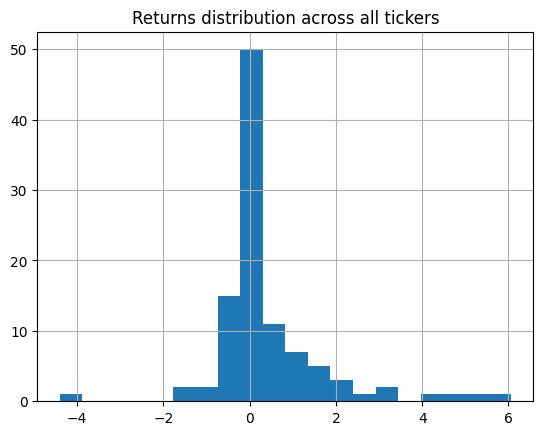

In [43]:
from matplotlib import pyplot as plt
plt.hist(returns_arr, bins=20)
plt.title("Returns distribution across all tickers")
plt.grid()
plt.show()